1. Cargar la base desde interim

In [ ]:
# ========================
#  1. Cargar dataset limpio
# ========================

import pandas as pd
import numpy as np

# Cargar la base ya limpia desde la carpeta interim
# (salida del notebook 05_data_cleaning)
df = pd.read_csv('../data/interim/hotel_bookings_clean.csv')

# Verificar primeras filas
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type_B,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,assigned_room_type_H,assigned_room_type_I,assigned_room_type_K,assigned_room_type_L
0,0,7,2015,July,27,1,0,1,1,0,...,False,True,False,False,False,False,False,False,False,False
1,0,13,2015,July,27,1,0,1,1,0,...,False,False,False,False,False,False,False,False,False,False
2,0,14,2015,July,27,1,0,2,2,0,...,False,False,False,False,False,False,False,False,False,False
3,0,0,2015,July,27,1,0,2,2,0,...,False,True,False,False,False,False,False,False,False,False
4,0,9,2015,July,27,1,0,2,2,0,...,False,True,False,False,False,False,False,False,False,False


# 2. Crear variables derivadas (features)

Nombre: total_nights
Cálculo: Suma de noches de semana y fin de semana.
Justificación: La duración total de la estadía puede influir en la probabilidad de cancelación, ya que reservas más largas implican mayor compromiso por parte del cliente.

In [3]:
# ========================
# 2.1 Total de noches
# ========================

# Sumamos noches de semana + fin de semana
# Esta variable captura la duración total de la estadía
df['total_nights'] = (
    df['stays_in_week_nights'] +
    df['stays_in_weekend_nights']
)

Nombre: total_guests

Cálculo:
Se obtiene sumando el número de adultos, niños y bebés incluidos en la reserva.

Justificación:
El tamaño del grupo puede influir en el comportamiento de reserva y cancelación. Por ejemplo, grupos más grandes suelen planificar con mayor anticipación y tienen menos flexibilidad para cancelar, mientras que reservas individuales pueden ser más volátiles. Esta variable permite capturar dichas diferencias en el análisis.

In [4]:
# ========================
# 2.2 Total de huéspedes
# ========================

# Sumamos adultos, niños y bebés
# Esto permite analizar el tamaño del grupo
df['total_guests'] = (
    df['adults'] +
    df['children'] +
    df['babies']
)

Nombre: total_price

Cálculo:
Se obtiene multiplicando la tarifa diaria promedio (ADR) por el número total de noches de la estadía.

Justificación:
Esta variable permite aproximar el valor total de la reserva, lo cual puede influir en la decisión de cancelación. Reservas de mayor valor económico pueden presentar comportamientos distintos, ya sea por mayor compromiso del cliente o por mayor sensibilidad al precio.

In [5]:
# ========================
# 2.3 Precio total estimado
# ========================

# Multiplicamos el precio por noche (ADR) por el total de noches
# Nos da una aproximación del valor total de la reserva
df['total_price'] = df['adr'] * df['total_nights']

Nombre: price_per_person
Cálculo: ADR dividido entre el número total de huéspedes.
Justificación: Permite analizar el costo individual de la reserva, lo cual puede influir en la decisión de cancelar.

In [6]:
# ========================
# 2.4 Precio por persona
# ========================

# Evitamos división por cero reemplazando 0 por NaN
df['price_per_person'] = df['adr'] / df['total_guests'].replace(0, np.nan)

Nombre: is_loyal

Cálculo:
Se transforma la variable is_repeated_guest en una variable binaria, donde 1 indica que el cliente es recurrente y 0 que no lo es.

Justificación:
Los clientes recurrentes pueden tener un comportamiento distinto frente a las cancelaciones, ya que suelen tener mayor confianza en el servicio y una relación previa con el hotel. Esta variable permite capturar ese nivel de fidelidad y su posible impacto en la probabilidad de cancelación.

In [7]:
# ========================
# 2.6 Cliente recurrente
# ========================

# Convertimos a variable binaria clara
df['is_loyal'] = (df['is_repeated_guest'] == 1).astype(int)

# 3. Variables de fecha

Nombre: arrival_month_num

Cálculo:
Se convierte la variable categórica arrival_date_month (nombre del mes) a su equivalente numérico (1 a 12) mediante un mapeo manual.

Justificación:
Esta transformación permite representar el mes de llegada como una variable numérica, facilitando su uso en modelos y análisis. Además, permite capturar patrones temporales y estacionales en las reservas y cancelaciones, que podrían no ser evidentes en formato categórico.

In [8]:
# ========================
# 3.1 Mes en formato numérico
# ========================

# Convertimos el nombre del mes a número para facilitar análisis
month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}

df['arrival_month_num'] = df['arrival_date_month'].map(month_map)

In [18]:
# ========================
# Alta temporada basada en demanda
# ========================

# Contamos reservas por mes
month_counts = df['arrival_date_month'].value_counts()

# Definimos como alta temporada los meses por encima del promedio
high_season_months = month_counts[month_counts > month_counts.mean()].index

# Creamos variable binaria
df['is_high_season'] = df['arrival_date_month'].isin(high_season_months).astype(int)

Se definió la variable de temporada alta en función del análisis de la distribución de reservas y tasas de cancelación por mes. Se identificó que julio y agosto presentan los mayores niveles de demanda y cancelación, por lo que se consideran meses de alta temporada.

# 4. Binning 

In [19]:
df['lead_time'].describe()

count    86372.000000
mean        80.126962
std         85.966221
min          0.000000
25%         12.000000
50%         50.000000
75%        125.000000
max        709.000000
Name: lead_time, dtype: float64

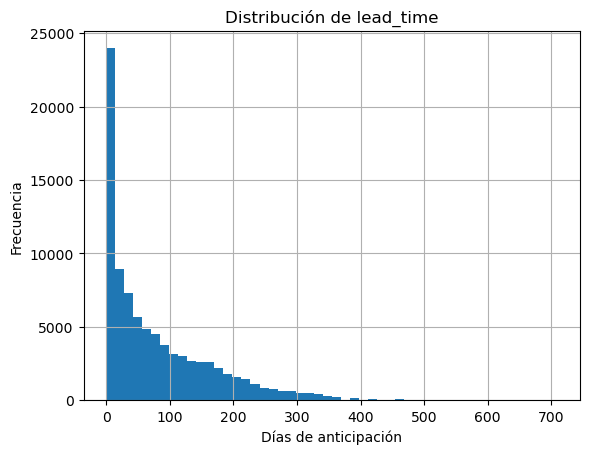

In [20]:
import matplotlib.pyplot as plt

df['lead_time'].hist(bins=50)
plt.title('Distribución de lead_time')
plt.xlabel('Días de anticipación')
plt.ylabel('Frecuencia')
plt.show()

Se aplicó binning sobre la variable lead_time con el objetivo de agrupar las reservas según su nivel de anticipación.

El análisis exploratorio mostró que la distribución de lead_time está sesgada hacia valores bajos, con una alta concentración de reservas realizadas con poca anticipación y una cola larga de valores extremos.

Por ello, se definieron rangos no uniformes que reflejan esta distribución, permitiendo capturar comportamientos diferenciados entre reservas de última hora, anticipación media y reservas muy anticipadas.

In [21]:
# ========================
# Binning de lead_time
# ========================

# La variable lead_time (días de anticipación) presenta una distribución sesgada,
# con alta concentración en valores bajos y una cola larga hacia valores altos.

# Por ello, agrupamos los valores en categorías que representen distintos niveles de anticipación

df['lead_time_group'] = pd.cut(
    df['lead_time'],  
    bins=[0, 7, 30, 90, 180, 700],  # rangos definidos según la distribución observada
    labels=[
        'last_minute',   # reservas hechas con muy poca anticipación (0–7 días)
        'short',         # reservas cercanas (7–30 días)
        'medium',        # anticipación moderada (30–90 días)
        'long',          # alta anticipación (90–180 días)
        'very_long'      # reservas muy anticipadas (más de 180 días)
    ]
)

In [22]:
# Ver cuántos registros hay en cada grupo
df['lead_time_group'].value_counts()

lead_time_group
medium         22554
long           18112
short          16205
last_minute    12166
very_long      11651
Name: count, dtype: int64

# 5. Interacciones entre variables

5.1. Precio por persona total

In [23]:
# ========================
# Interacción: precio total por persona
# ========================

# Relaciona el precio total con el número de huéspedes
df['price_per_person_total'] = df['total_price'] / df['total_guests']

Nombre: price_per_person_total

Cálculo:
División del precio total estimado entre el número total de huéspedes.

Justificación:
Permite analizar el costo individual de la reserva considerando la duración de la estadía. Esta variable puede influir en la decisión de cancelación, ya que precios elevados por persona podrían aumentar la probabilidad de cancelación.

In [ ]:
5.2. Lead time × total de noches

In [24]:
# ========================
# Interacción: anticipación y duración
# ========================

# Combina anticipación con duración de la estadía
df['lead_time_x_nights'] = df['lead_time'] * df['total_nights']

Nombre: lead_time_x_price

Cálculo:
Producto entre la variable lead_time y la tarifa diaria promedio (ADR).

Justificación:
Esta variable captura la interacción entre el tiempo de anticipación y el costo de la reserva. Es relevante porque reservas realizadas con mucha anticipación y alto costo pueden presentar un comportamiento distinto en términos de cancelación en comparación con reservas de bajo costo o realizadas a último momento.

5.3 lead_time_x_nights

In [25]:
# ========================
# Interacción: anticipación y duración
# ========================

# Combina anticipación con duración de la estadía
df['lead_time_x_nights'] = df['lead_time'] * df['total_nights']

Nombre: lead_time_x_nights

Cálculo:
Producto entre el tiempo de anticipación (lead_time) y el número total de noches.

Justificación:
Esta variable combina la anticipación de la reserva con la duración de la estadía, permitiendo capturar comportamientos más complejos. Reservas largas realizadas con mucha anticipación pueden tener patrones de cancelación diferentes a reservas cortas o de última hora.

# 6. Transformaciones de variables

6.1 Transformación logarítmica de ADR

In [26]:
# ========================
# Transformación logarítmica de ADR
# ========================

# Aplicamos log(1 + x) para evitar problemas con valores cero
# Reduce la asimetría y el impacto de valores extremos
df['adr_log'] = np.log1p(df['adr'])

Nombre: adr_log

Cálculo:
Se aplica la transformación logarítmica log(1 + ADR) para reducir la asimetría de la variable.

Justificación:
La variable ADR presenta una distribución sesgada con presencia de valores extremos. La transformación logarítmica permite estabilizar la varianza y reducir el impacto de outliers, facilitando el aprendizaje del modelo.

In [28]:
# ========================
# Transformación logarítmica de lead_time
# ========================

# Reduce la cola larga observada en la distribución
df['lead_time_log'] = np.log1p(df['lead_time'])

Nombre: lead_time_log

Cálculo:
Se aplica la transformación logarítmica log(1 + lead_time).

Justificación:
La variable lead_time presenta una distribución altamente sesgada hacia valores bajos con una cola larga. Esta transformación permite comprimir la escala de valores altos, mejorando la representación de la variable en modelos predictivos.

# 7. CORRELACIÓN (redundancia)

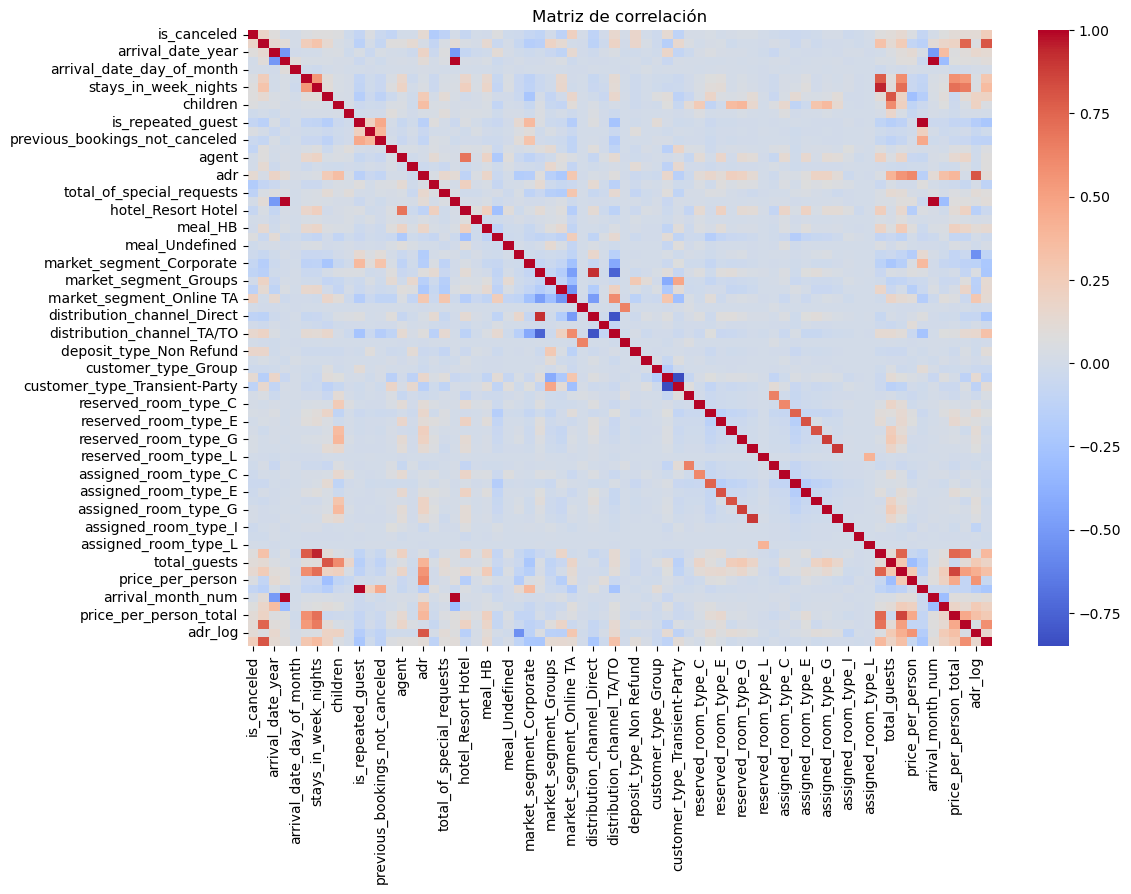

In [29]:
# ========================
# Matriz de correlación
# ========================

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos variables numéricas
corr_matrix = df.corr(numeric_only=True)

# Visualización
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

In [30]:
# ========================
# Correlaciones más altas
# ========================

corr_matrix = df.corr(numeric_only=True)

# Convertimos a formato tabla
corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .reset_index()
)

# Renombramos columnas
corr_pairs.columns = ['var1', 'var2', 'correlation']

# Eliminamos duplicados y auto-correlaciones
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs = corr_pairs.drop_duplicates(subset=['correlation'])

# Filtramos correlaciones altas
high_corr = corr_pairs[corr_pairs['correlation'] > 0.7]

# Ordenamos
high_corr.sort_values(by='correlation', ascending=False).head(10)

,var1,var2,correlation
763,is_repeated_guest,is_loyal,1.000000
229,arrival_date_week_number,arrival_date_month_num,0.995065
479,stays_in_week_nights,total_nights,0.949164
1922,market_segment_Direct,distribution_channel_Direct,0.917242
3345,reserved_room_type_H,assigned_room_type_H,0.894927
3274,reserved_room_type_G,assigned_room_type_G,0.882558
4336,total_price,price_per_person_total,0.859630
2770,customer_type_Transient,customer_type_Transient-Party,0.849500
3203,reserved_room_type_F,assigned_room_type_F,0.818879
3132,reserved_room_type_E,assigned_room_type_E,0.816709


In [32]:
df.columns

Index(['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month',
       'arrival_date_week_number', 'arrival_date_day_of_month',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'country', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes', 'agent',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'arrival_date_month_num',
       'hotel_Resort Hotel', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined',
       'market_segment_Complementary', 'market_segment_Corporate',
       'market_segment_Direct', 'market_segment_Groups',
       'market_segment_Offline TA/TO', 'market_segment_Online TA',
       'market_segment_Undefined', 'distribution_channel_Direct',
       'distribution_channel_GDS', 'distribution_channel_TA/TO',
       'distribution_channel_Undefined', 'deposit_type_Non Refund',
       'deposit_type_Refundable',

In [33]:
# ========================
# Eliminación de variables redundantes
# ========================

# Eliminamos variables altamente correlacionadas o redundantes
df.drop([
    # Duplicadas por feature engineering
    'is_repeated_guest',          # ya representada por is_loyal
    
    # Variables temporales redundantes
    'arrival_date_week_number',   # redundante con arrival_month_num
    
    # Redundancia con total_nights
    'stays_in_week_nights',       # ya incluida en total_nights

    
    # Redundancia en precio
    'total_price',                # altamente correlacionada con price_per_person_total
    
    # Opcional (elige uno de estos dos si quieres simplificar más)
    # 'market_segment_Direct',
    # 'distribution_channel_Direct'
    
], axis=1, inplace=True)

print("Variables redundantes eliminadas correctamente")

Variables redundantes eliminadas correctamente


In [34]:
# ========================
# Eliminación correcta por prefijos
# ========================

cols_to_drop = []

# Columnas que contienen 'reserved_room_type'
cols_to_drop += [col for col in df.columns if 'reserved_room_type_' in col]

# Columnas que contienen 'assigned_room_type'
cols_to_drop += [col for col in df.columns if 'assigned_room_type_' in col]

# Eliminación final
df.drop(cols_to_drop, axis=1, inplace=True)

print("Columnas eliminadas:", cols_to_drop)

Columnas eliminadas: ['reserved_room_type_B', 'reserved_room_type_C', 'reserved_room_type_D', 'reserved_room_type_E', 'reserved_room_type_F', 'reserved_room_type_G', 'reserved_room_type_H', 'reserved_room_type_L', 'assigned_room_type_B', 'assigned_room_type_C', 'assigned_room_type_D', 'assigned_room_type_E', 'assigned_room_type_F', 'assigned_room_type_G', 'assigned_room_type_H', 'assigned_room_type_I', 'assigned_room_type_K', 'assigned_room_type_L']


In [35]:
# ========================
# Guardar dataset con feature engineering
# ========================

df.to_csv('../data/interim/hotel_bookings_fe.csv', index=False)

print("Dataset guardado correctamente en interim")

Dataset guardado correctamente en interim
